<a href="https://colab.research.google.com/github/SandraM133/workforce-demand-analysis/blob/main/Scheduling_%26_Demand_Analysis_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        date  hour  customers  sales  staff_scheduled
0 2025-12-01    12         45    620                5
1 2025-12-01    13         52    710                6
2 2025-12-01    18         80   1200                8
3 2025-12-02    12         48    650                5
4 2025-12-02    18         90   1350                9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             5 non-null      datetime64[ns]
 1   hour             5 non-null      int64         
 2   customers        5 non-null      int64         
 3   sales            5 non-null      int64         
 4   staff_scheduled  5 non-null      int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 332.0 bytes
None
                      date       hour  customers       sales  staff_scheduled
count                    5   5.000000   5.000000     5.00000

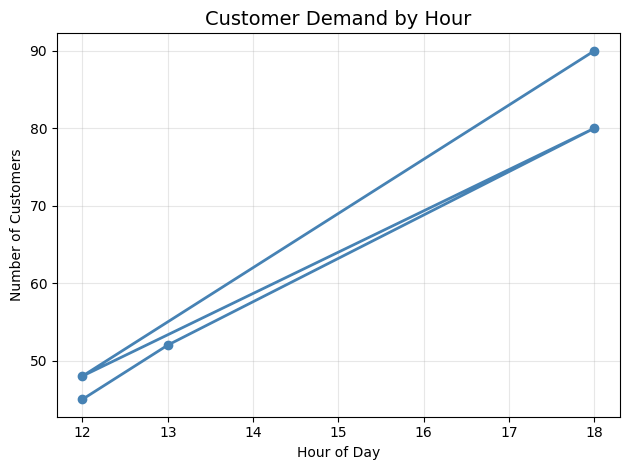

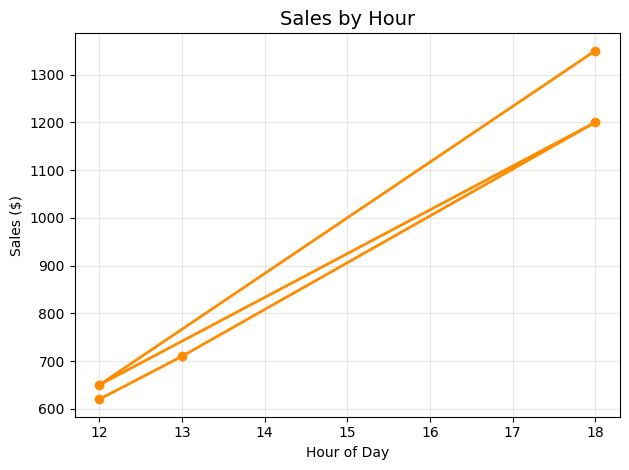


Hourly Average Sales (Baseline Forecast):
hour
12     635.0
13     710.0
18    1275.0
Name: sales, dtype: float64


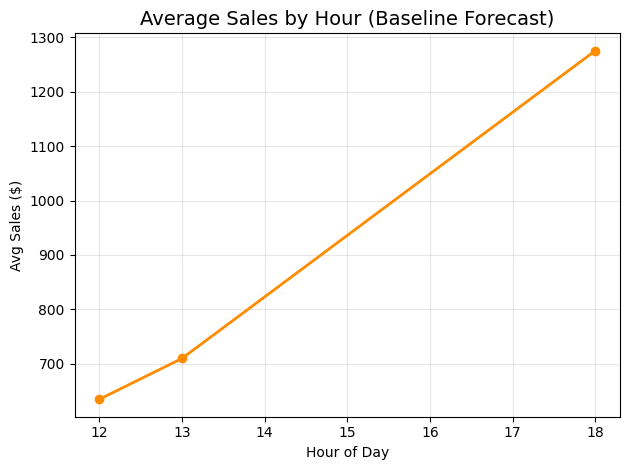

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. DATA SETUP ─────────────────────────────────────────────────────────────
data = {
    "date": ["2025-12-01", "2025-12-01", "2025-12-01", "2025-12-02", "2025-12-02"],
    "hour": [12, 13, 18, 12, 18],
    "customers": [45, 52, 80, 48, 90],
    "sales": [620, 710, 1200, 650, 1350],
    "staff_scheduled": [5, 6, 8, 5, 9],
}

df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"])  # fix date dtype

# ── 2. EXPLORATORY DATA ANALYSIS ──────────────────────────────────────────────
print(df.head())
print(df.info())
print(df.describe())
print(df[["customers", "sales", "staff_scheduled"]].corr())

# ── 3. ADDITIONAL METRICS ─────────────────────────────────────────────────────
df["sales_per_staff"] = df["sales"] / df["staff_scheduled"]
print("\nSales per Staff Member by Hour:")
print(df[["hour", "sales_per_staff"]])

# ── 4. VISUALIZATIONS ─────────────────────────────────────────────────────────

# Customer demand by hour
plt.plot(df["hour"], df["customers"], marker="o", color="steelblue", linewidth=2)
plt.title("Customer Demand by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Customers")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sales by hour (raw)
plt.plot(df["hour"], df["sales"], marker="o", color="darkorange", linewidth=2)
plt.title("Sales by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Sales ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 5. DEMAND FORECAST (hourly averages) ──────────────────────────────────────
result = df.groupby("hour")["sales"].mean()
print("\nHourly Average Sales (Baseline Forecast):")
print(result)

# Forecast plot using averaged data
result.plot(marker="o", color="darkorange", linewidth=2)
plt.title("Average Sales by Hour (Baseline Forecast)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Avg Sales ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
